# Dry Spell Warning — Starter Notebook (Baseline)

This notebook shows how to:

1. Load a few provided feature files
2. Load the training labels (`solution_train.csv`)
3. Train a simple Logistic Regression baseline
4. Generate `submission.csv` and `submittion.zip`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Dependencies

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score , confusion_matrix
#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier
#Over and Under Sampling
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss

DATA_DIR = Path("/content/drive/MyDrive/public_data/input_data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

LABEL_COL = "dryspell_warn_7d"   # target label column in solution_train.csv
DATE_COL  = "date"              # merge key


## 1) **Load feature files + labels (train)**

Then merge them on `date`.


In [ ]:
def load_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    return df

slp = load_csv(TRAIN_DIR / "sea level pressure era5_train.csv")
tmp = load_csv(TRAIN_DIR / "temp_trimmed_train.csv")
vpd = load_csv(TRAIN_DIR / "vapour pressure deficit_train.csv")
soil_moist = load_csv(TRAIN_DIR / "5cm soil moist CFS_train.csv")
dew_point = load_csv(TRAIN_DIR / "dew point_train.csv")
max_st = load_csv(TRAIN_DIR / "max surface temp era5 max_train.csv")
sud_water_deficit = load_csv(TRAIN_DIR / "sudd water deficit_train.csv")
y   = load_csv(TRAIN_DIR / "solution_train.csv")



df_train = y.merge(slp, on=DATE_COL, how="inner") \
            .merge(tmp, on=DATE_COL, how="inner") \
            .merge(vpd, on=DATE_COL, how="inner") \
            .merge(soil_moist, on=DATE_COL, how="inner")\
            .merge(dew_point, on=DATE_COL, how="inner")\
            .merge(max_st, on=DATE_COL, how="inner") \
            .merge(sud_water_deficit,on=DATE_COL,how="inner")

df_train = df_train.sort_values(DATE_COL).reset_index(drop=True)
df_train.head()


,date,dryspell_warn_7d,sea_level_pressure,2m_temp,vapor_pressure_dificit,5cm_soli_moist,mean_dew_point_temp,max_temp,potential_water_deficit
0,2002-07-01,0,101.0101,32.7337,5.4509,0.1391,16.3077,40.1287,-4.6066
1,2002-07-02,0,100.8131,33.3701,5.5227,0.1378,16.7714,41.3576,-2.9165
2,2002-07-03,0,100.9677,31.5651,4.2252,0.1371,19.7184,38.0545,7.5906
3,2002-07-04,0,100.9361,32.5935,4.6788,0.1365,18.5050,39.5121,-2.2922
4,2002-07-05,0,100.8596,33.5925,5.1532,0.1373,17.6835,40.4695,-2.8745


## 2)**Load feature files + labels (test)**

We load the matching test feature files, merge on `date`, and predict.

We output `dryspell_warn_7d` as **0/1**


In [ ]:
slp_t = load_csv(TEST_DIR / "sea level pressure era5_test.csv")
tmp_t = load_csv(TEST_DIR / "temp_trimmed_test.csv")
vpd_t = load_csv(TEST_DIR / "vapour pressure deficit_test.csv")
soil_moist_t = load_csv(TEST_DIR / "5cm soil moist CFS_test.csv")
dew_point_t = load_csv(TEST_DIR / "dew point_test.csv")
max_st_t = load_csv(TEST_DIR / "max surface temp era5 max_test.csv")
sud_water_deficit_t = load_csv(TEST_DIR / "sudd water deficit_test.csv")


In [ ]:
dfs = [slp_t, tmp_t, vpd_t,soil_moist_t,dew_point_t,max_st_t,sud_water_deficit_t]

In [ ]:
from functools import reduce
dfs = [d.groupby(DATE_COL, as_index=False).mean(numeric_only=True) for d in dfs]

# Union of all dates across files
df_test = reduce(lambda left, right: left.merge(right, on=DATE_COL, how="outer"), dfs)

df_test = df_test.ffill()

# Sort + clean
df_test[DATE_COL] = pd.to_datetime(df_test[DATE_COL])
df_test = df_test.sort_values(DATE_COL).reset_index(drop=True)
df_test.head()


,date,sea_level_pressure,2m_temp,vapor_pressure_dificit,5cm_soli_moist,mean_dew_point_temp,max_temp,potential_water_deficit
0,2020-07-01,100.6739,32.3152,4.9632,0.2456,16.2610,39.0313,-4.1004
1,2020-07-02,100.7870,31.1876,4.1520,0.2292,18.4580,36.9607,-3.3462
2,2020-07-03,100.8407,30.9356,4.5619,0.2222,16.2286,37.1146,-4.7923
3,2020-07-04,100.8388,31.9801,5.0776,0.2107,16.3607,39.2223,-1.2271
4,2020-07-05,100.6846,31.3877,4.2320,0.2105,16.5931,37.4637,-3.7262


## **Exploaring the Data**

In [ ]:
print("The shape of the trainning data", df_train.shape)
print("The shape of the testing data",df_test.shape)

The shape of the trainning data (2214, 9)
The shape of the testing data (738, 8)


In [ ]:
df_train.isnull().sum()

,0
date,0
dryspell_warn_7d,0
sea_level_pressure,0
2m_temp,0
vapor_pressure_dificit,0
5cm_soli_moist,0
mean_dew_point_temp,0
max_temp,0
potential_water_deficit,0


In [ ]:
df_test.isnull().sum()

,0
date,0
sea_level_pressure,0
2m_temp,0
vapor_pressure_dificit,0
5cm_soli_moist,0
mean_dew_point_temp,0
max_temp,0
potential_water_deficit,0


**Features Distributions**

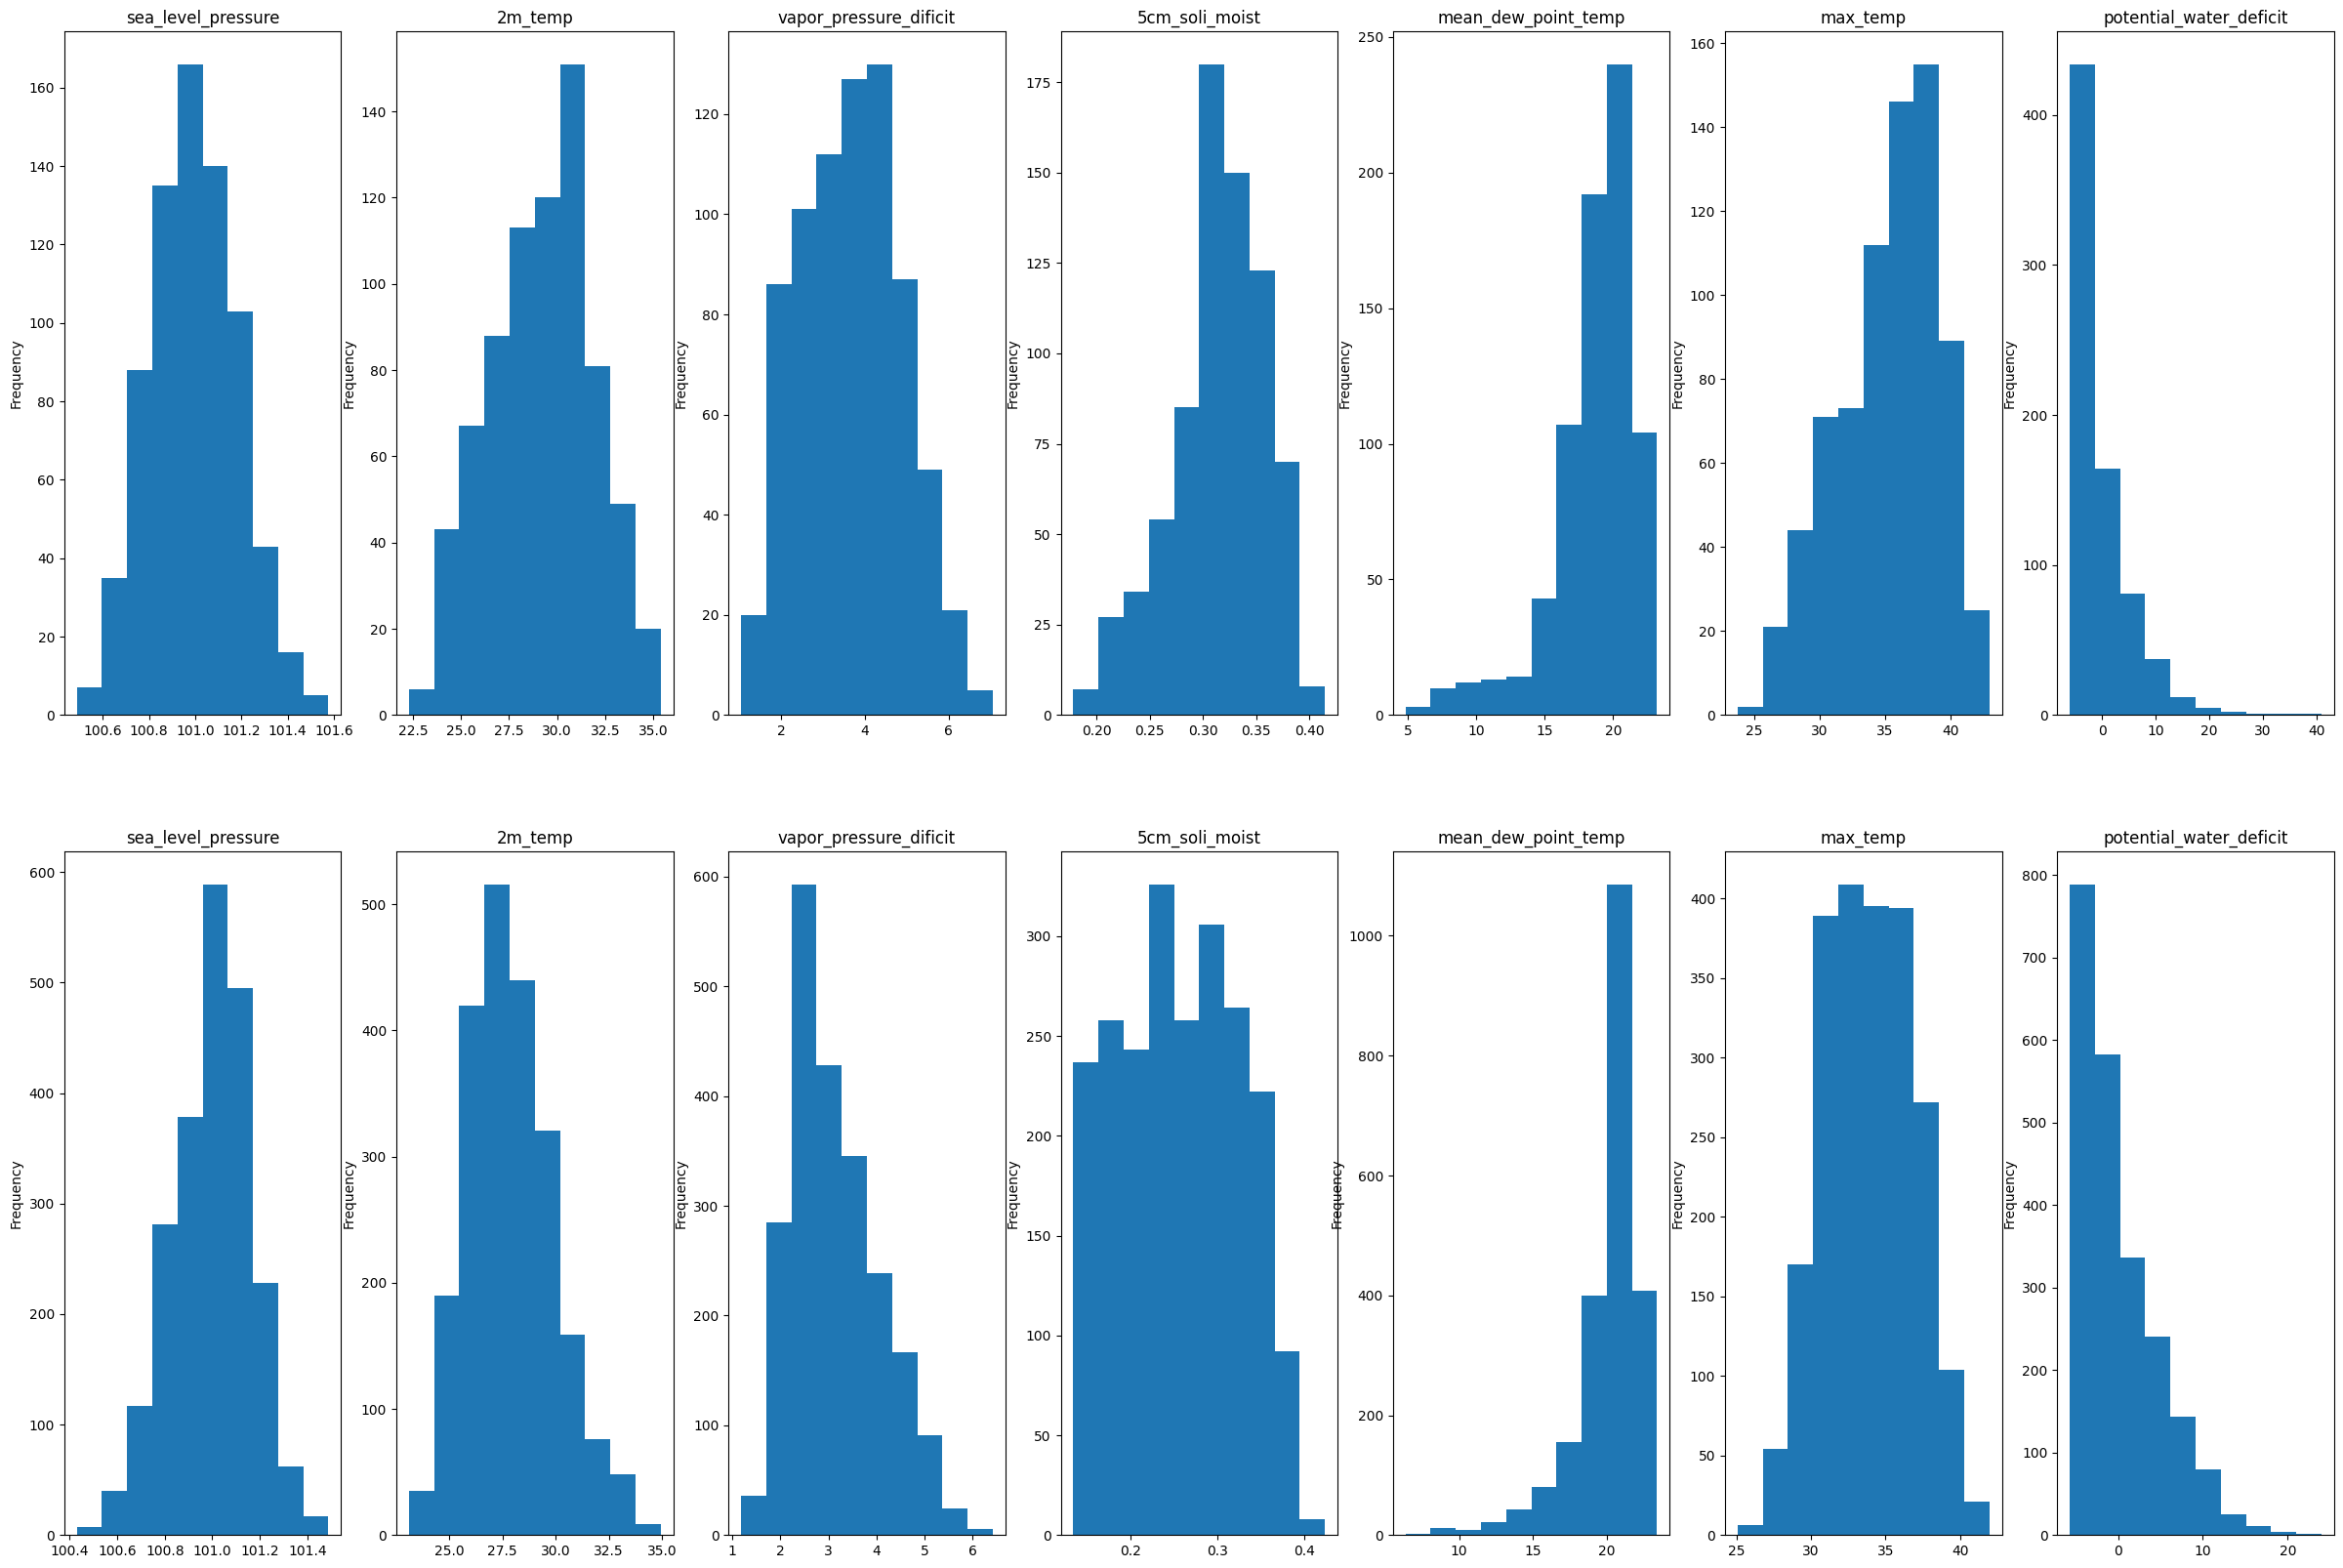

In [ ]:
features = ["sea_level_pressure","2m_temp","vapor_pressure_dificit","5cm_soli_moist","mean_dew_point_temp","max_temp","potential_water_deficit"]

fig , ax = plt.subplots(2,7,figsize=(30,20))
for i,feature in enumerate(features):
    df_train[feature].plot(kind="hist",ax=ax[1][i])
    ax[0][i].set_title(feature)
    df_test[feature].plot(kind="hist",ax=ax[0][i])
    ax[1][i].set_title(feature)
plt.show()

In [ ]:
df_train.dryspell_warn_7d.value_counts()

,count
dryspell_warn_7d,
0,1890
1,324


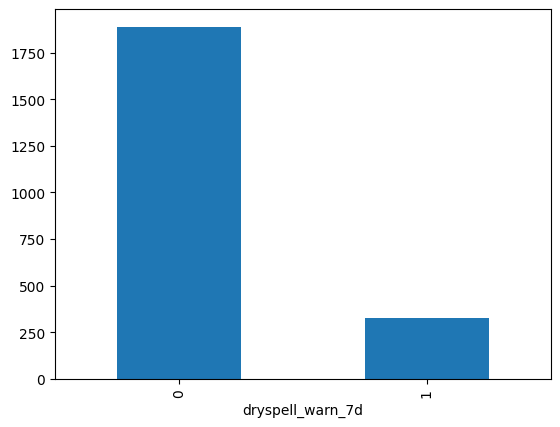

In [ ]:
df_train.dryspell_warn_7d.value_counts().plot.bar()
plt.show()

Clear imbalance in the target

**Checking Target distribution against other features**

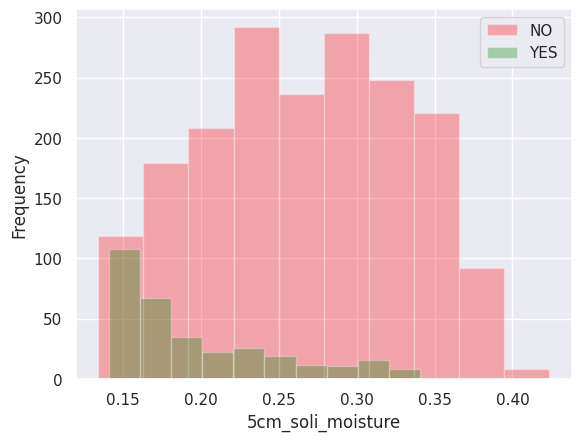

In [ ]:
sns.set()
plt.hist(df_train[df_train['dryspell_warn_7d'] == 0]['5cm_soli_moist'], color='red', alpha = 0.3, label = 'NO')
plt.hist(df_train[df_train['dryspell_warn_7d'] == 1]['5cm_soli_moist'], color='green', alpha=0.3, label = 'YES')
plt.legend()
plt.xlabel("5cm_soli_moisture")
plt.ylabel("Frequency")
plt.plot()
plt.show()

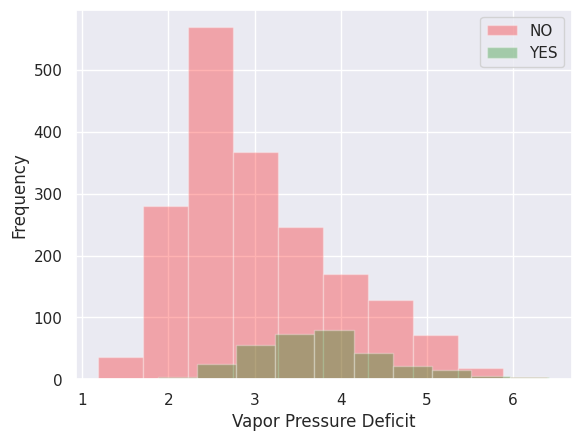

In [ ]:
sns.set()
plt.hist(df_train[df_train['dryspell_warn_7d'] == 0]['vapor_pressure_dificit'], color='red', alpha = 0.3, label = 'NO')
plt.hist(df_train[df_train['dryspell_warn_7d'] == 1]['vapor_pressure_dificit'], color='green', alpha=0.3, label = 'YES')
plt.legend()
plt.xlabel("Vapor Pressure Deficit")
plt.ylabel("Frequency")
plt.plot()
plt.show()

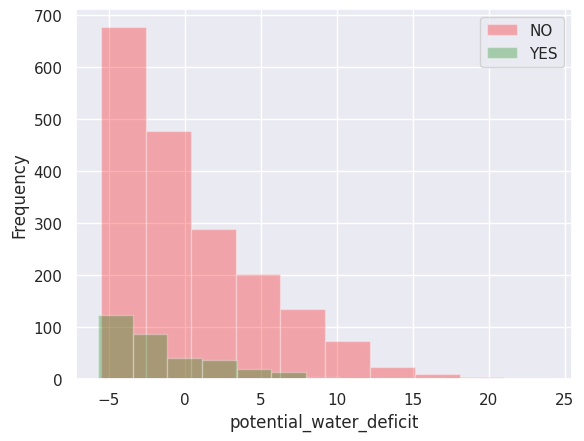

In [ ]:
sns.set()
plt.hist(df_train[df_train['dryspell_warn_7d'] == 0]['potential_water_deficit'], color='red', alpha = 0.3, label = 'NO')
plt.hist(df_train[df_train['dryspell_warn_7d'] == 1]['potential_water_deficit'], color='green', alpha=0.3, label = 'YES')
plt.legend()
plt.xlabel("potential_water_deficit")
plt.ylabel("Frequency")
plt.plot()
plt.show()

In [ ]:
df_train[(df_train["potential_water_deficit"]>15) & (df_train["dryspell_warn_7d"]==0)].count()

,0
dryspell_warn_7d,41
sea_level_pressure,41
2m_temp,41
vapor_pressure_dificit,41
5cm_soli_moist,41
mean_dew_point_temp,41
max_temp,41
potential_water_deficit,41
day,41
month,41


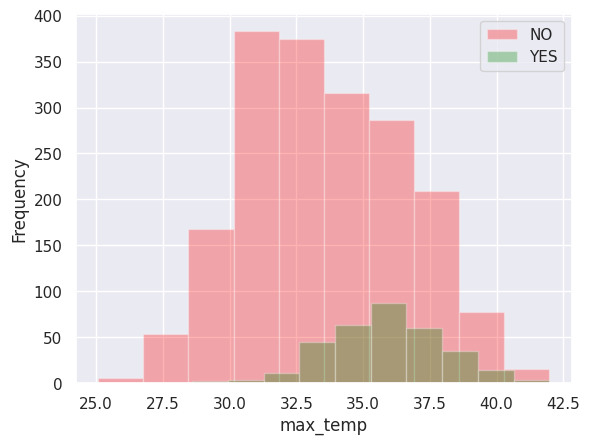

In [ ]:
sns.set()
plt.hist(df_train[df_train['dryspell_warn_7d'] == 0]['max_temp'], color='red', alpha = 0.3, label = 'NO')
plt.hist(df_train[df_train['dryspell_warn_7d'] == 1]['max_temp'], color='green', alpha=0.3, label = 'YES')
plt.legend()
plt.xlabel("max_temp")
plt.ylabel("Frequency")
plt.plot()
plt.show()

In [ ]:
df_train[(df_train["max_temp"]<=30) & (df_train["dryspell_warn_7d"]==1)]

,dryspell_warn_7d,sea_level_pressure,2m_temp,vapor_pressure_dificit,5cm_soli_moist,mean_dew_point_temp,max_temp,potential_water_deficit,day,month,year,dayofweek,dayofyear
date,,,,,,,,,,,,,
2004-10-06,1,101.3555,25.3939,1.8791,0.1826,21.3817,28.6104,-4.7886,6,10,2004,2,280
2014-10-15,1,101.1499,25.0643,2.0732,0.3152,22.3375,28.9569,-2.7268,15,10,2014,2,288


We can use this observation to make a new feature

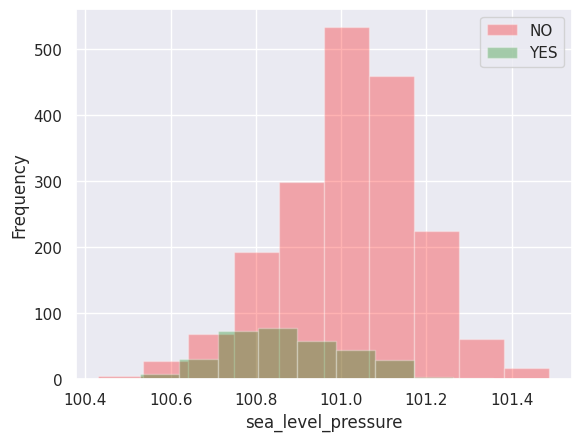

In [ ]:
sns.set()
plt.hist(df_train[df_train['dryspell_warn_7d'] == 0]['sea_level_pressure'], color='red', alpha = 0.3, label = 'NO')
plt.hist(df_train[df_train['dryspell_warn_7d'] == 1]['sea_level_pressure'], color='green', alpha=0.3, label = 'YES')
plt.legend()
plt.xlabel("sea_level_pressure")
plt.ylabel("Frequency")
plt.plot()
plt.show()

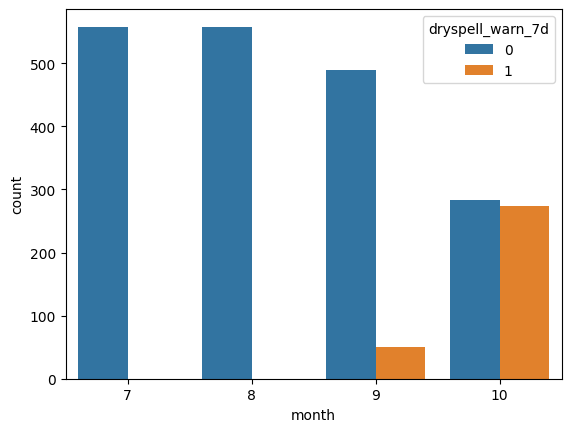

In [ ]:
sns.countplot(x="month",data=df_train,hue="dryspell_warn_7d")
plt.show()
#

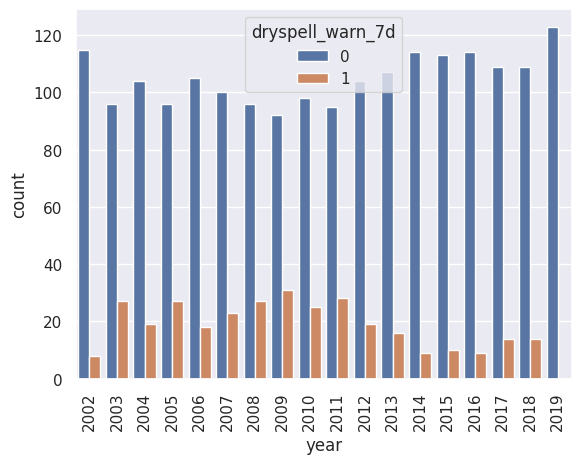

In [ ]:
sns.countplot(x="year",data=df_train,hue="dryspell_warn_7d")
plt.xticks(rotation=90)
plt.show()

## **Feature Extraction**


In [ ]:
df_train["day"]=df_train["date"].dt.day
df_train["year"]=df_train["date"].dt.year
df_train["dayofyear"]=df_train["date"].dt.dayofyear
df_train= df_train.set_index("date")

In [ ]:
df_test["day"]=df_test["date"].dt.day
df_test["year"]=df_test["date"].dt.year
df_test["dayofyear"]=df_test["date"].dt.dayofyear
df_test= df_test.set_index("date")


In [ ]:
df_train.describe()

,dryspell_warn_7d,sea_level_pressure,2m_temp,vapor_pressure_dificit,5cm_soli_moist,mean_dew_point_temp,max_temp,potential_water_deficit,day,month,year,dayofweek,dayofyear
count,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000,2214.0000,2214.000000,2214.000000
mean,0.146341,100.998690,27.913380,3.153928,0.256045,20.156803,33.897412,0.121764,15.878049,8.495935,2010.5000,2.996387,243.222222
std,0.353528,0.165691,2.038023,0.921981,0.067658,2.209222,3.000771,4.618444,8.879295,1.121910,5.1893,2.000674,35.516324
min,0.000000,100.430100,23.107400,1.186200,0.134200,6.371100,25.085700,-5.697400,1.000000,7.000000,2002.0000,0.000000,182.000000
25%,0.000000,100.885750,26.415650,2.433950,0.200975,19.554325,31.564625,-3.567375,8.000000,7.000000,2006.0000,1.000000,212.250000
50%,0.000000,101.013300,27.705050,2.955750,0.254700,20.851150,33.800150,-1.305150,16.000000,8.000000,2010.5000,3.000000,243.000000
75%,0.000000,101.113100,29.203625,3.774625,0.310375,21.548550,36.200475,2.764450,24.000000,10.000000,2015.0000,5.000000,274.000000
max,1.000000,101.488200,34.928700,6.418100,0.423600,23.419300,41.970000,23.975200,31.000000,10.000000,2019.0000,6.000000,305.000000


In [ ]:
df_test.describe()

,sea_level_pressure,2m_temp,vapor_pressure_dificit,5cm_soli_moist,mean_dew_point_temp,max_temp,potential_water_deficit,day,month,year,dayofweek,dayofyear
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000
mean,100.996781,29.205158,3.678069,0.314433,18.659678,35.274832,-0.300159,15.878049,8.495935,2022.500000,3.004065,243.333333
std,0.185299,2.690931,1.197091,0.043833,3.055066,3.763653,5.524701,8.883310,1.122417,1.708983,1.998978,35.533079
min,100.486900,22.301000,1.047100,0.178100,4.802900,23.704500,-5.995000,1.000000,7.000000,2020.000000,0.000000,182.000000
25%,100.862900,27.159500,2.718800,0.290325,17.447975,32.599600,-4.035700,8.000000,7.000000,2021.000000,1.000000,213.000000
50%,101.000800,29.326100,3.717350,0.317950,19.328650,35.939600,-2.299100,16.000000,8.000000,2022.500000,3.000000,243.000000
75%,101.129625,31.186050,4.517150,0.347075,20.700050,38.099825,1.806875,24.000000,10.000000,2024.000000,5.000000,274.000000
max,101.577000,35.389400,7.047100,0.414600,23.219600,42.953500,40.930700,31.000000,10.000000,2025.000000,6.000000,305.000000


**Aggregation Features**

In [ ]:
def Agg(Feature):
    for dataset in (df_train,df_test):
        dataset[f'Mean{Feature}PerDayOfYear'] = dataset['dayofyear'].map(dict(dataset.groupby('dayofyear')[Feature].mean()))
        dataset[f'Median{Feature}PerDayOfYear'] = dataset['dayofyear'].map(dict(dataset.groupby('dayofyear')[Feature].median()))

Agg("vapor_pressure_dificit")
Agg("potential_water_deficit")
Agg("5cm_soli_moist")
Agg("max_temp")

**Lag Features**

In [ ]:
def Lag(Feature):
    for df in (df_train,df_test):
        df[f'{Feature}_Lag1'] = df.groupby('year')[Feature].shift(1)

# Create a 3-day rolling sum (How many drought days in the last 3 days?)
        df[f'{Feature}_Recent_Intensity'] = df.groupby('year')[Feature].transform(
            lambda x: x.shift(1).rolling(window=3).sum()
        )

Lag("5cm_soli_moist")
Lag("vapor_pressure_dificit")
Lag("potential_water_deficit")

In [ ]:
df_train['dryspell_warn_7d_lag1'] = df_train.groupby('year')['dryspell_warn_7d'].shift(1)

df_train['target_seasonal_count'] = df_train.groupby('year')['dryspell_warn_7d'].transform(
    lambda x: x.shift(1).expanding().sum()
)

df_train['target_roll_7'] = df_train.groupby('year')['dryspell_warn_7d'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

In [ ]:
df_train['dryspell_warn_7d_lag3'] = df_train.groupby('year')['dryspell_warn_7d'].shift(3)

In [ ]:
df_train['dryspell_warn_7d_lag1'] =df_train['dryspell_warn_7d_lag1'].bfill()
df_train['target_seasonal_count'] = df_train['target_seasonal_count'].bfill()
df_train['target_roll_7'] = df_train['target_roll_7'].bfill()

In [ ]:
df_train['dryspell_warn_7d_lag7'] = df_train['dryspell_warn_7d_lag7'].bfill()

In [ ]:
lag_target_feat= ['dryspell_warn_7d_lag7','target_seasonal_count','target_roll_7','dryspell_warn_7d_lag1']


In [ ]:
df_train.drop("dryspell_warn_7d_lag1",axis=1,inplace=True)

In [ ]:
print(df_train.shape)
print(df_test.shape)

(2214, 31)
(738, 30)


In [ ]:
for col in df_train.columns.to_list():
    if "Lag" in col:
        df_train[col] = df_train[col].fillna(df_train[col].mean())

In [ ]:
for col in df_test.columns.to_list():
    if "Lag" in col:
        df_test[col] = df_test[col].fillna(df_test[col].mean())

In [ ]:
for col in df_train.columns.to_list():
    if "_Intensity" in col:
        df_train[col] = df_train[col].bfill()

In [ ]:
for col in df_test.columns.to_list():
    if "_Intensity" in col:
      df_test[col] = df_test[col].bfill()

In [ ]:
df_test.tail()

,sea_level_pressure,2m_temp,vapor_pressure_dificit,5cm_soli_moist,mean_dew_point_temp,max_temp,potential_water_deficit,day,year,dayofyear,...,Mean5cm_soli_moistPerDayOfYear,Median5cm_soli_moistPerDayOfYear,Meanmax_tempPerDayOfYear,Medianmax_tempPerDayOfYear,5cm_soli_moist_Lag1,5cm_soli_moist_Recent_Intensity,vapor_pressure_dificit_Lag1,vapor_pressure_dificit_Recent_Intensity,potential_water_deficit_Lag1,potential_water_deficit_Recent_Intensity
date,,,,,,,,,,,,,,,,,,,,,
2025-10-27,100.8319,31.4210,5.4364,0.1910,9.2297,38.8222,-4.6914,27,2025,300,...,0.278433,0.27375,38.535300,38.86075,0.1954,0.6106,5.7810,16.6775,-4.5092,-13.2307
2025-10-28,100.7756,32.6911,5.5175,0.1874,9.3220,39.2205,-4.6645,28,2025,301,...,0.271450,0.26530,38.073217,38.76500,0.1910,0.5859,5.4364,17.1448,-4.6914,-13.6112
2025-10-29,100.7052,33.5798,6.0618,0.1912,11.2050,41.1797,-3.6759,29,2025,302,...,0.266967,0.25950,38.876067,39.27455,0.1874,0.5738,5.5175,16.7349,-4.6645,-13.8651
2025-10-30,100.6730,33.7738,5.9892,0.1812,11.1315,41.0777,-4.5788,30,2025,303,...,0.249383,0.24390,39.257467,39.86525,0.1912,0.5696,6.0618,17.0157,-3.6759,-13.0318
2025-10-31,100.8082,33.1179,5.4102,0.1781,10.3237,39.5474,-3.7049,31,2025,304,...,0.247000,0.23840,38.487200,39.05555,0.1812,0.5598,5.9892,17.5685,-4.5788,-12.9192


**Interactive Features**

In [ ]:
for df in (df_train,df_test):
    df['Temp_Diff_3d'] = df.groupby('year')['max_temp'].diff(3)

    # 2. Evaporative Proxy (Heat + Wind stress)
    # We add 1 to wind to avoid division by zero
    df['Evaporative_Proxy'] = df['vapor_pressure_dificit'] + 1

    # 3. Moving Weather Averages (Proxies for target lags)
    # These give the model 'memory' without the 'leakage' of target lags
    df['Temp_Roll_10d'] = df.groupby('year')['max_temp'].transform(lambda x: x.rolling(10).mean())
    df['5cm_soli_moist_Roll_10d'] = df.groupby('year')['5cm_soli_moist'].transform(lambda x: x.rolling(10).mean())

    # 4. Binary 'Heatwave' Memory
    # Did we have a heatwave in the last 14 days?
    df['Heatwave_Binary'] = (df['max_temp'] > df['max_temp'].quantile(0.9)).astype(int)
    df['Recent_Heatwave_Count'] = df.groupby('year')['Heatwave_Binary'].transform(
        lambda x: x.rolling(14).sum()
    )

    # Clean up
    df.fillna(0, inplace=True)

*Did not enhance the performance but it made it worse ,so I dropped them*

### Validation Using TimeSeriesSplit

**Models**

In [ ]:
clf = LogisticRegression(max_iter=3000,random_state=42)
rfc = RandomForestClassifier(random_state=42,max_depth=6)
xgb = XGBClassifier(n_estimators=1000,random_state=42,learning_rate=0.01,scale_pos_weight=5)
svm = SVC(C=500.0, kernel='rbf',random_state=42)

**Validation Function**

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
X = df_train.drop(['dryspell_warn_7d'],axis=1).values
y = df_train['dryspell_warn_7d'].values

In [ ]:
def validate_model_threshold(model,X,y):
  tscv = TimeSeriesSplit(n_splits=2)
  Accuracy_scores = []
  F1_scores = []


  for train_index, test_index in tscv.split(X):
      X_Train, X_Test = X[train_index], X[test_index]
      y_Train, y_Test = y[train_index], y[test_index]

      model.fit(X_Train, y_Train) # Add this line to fit the model
      proba = model.predict_proba(X_Test)[:, 1]
      y_pred = (proba >= 0.35).astype(int)

      cm = confusion_matrix(y_Test, y_pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # Fixed: Pass unique class labels
      disp.plot(cmap=plt.cm.Blues)
      plt.title('Confusion Matrix')
      plt.show()

      Accuracy_scores.append(accuracy_score(y_pred,y_Test))
      F1_scores.append(f1_score(y_pred,y_Test))

  print("Model Name: " , model)
  print("Scores:", Accuracy_scores,"F1_scores:", F1_scores)
  print("Mean Accuracy:",np.mean(Accuracy_scores))
  print("Mean F1 Score:",np.mean(F1_scores))

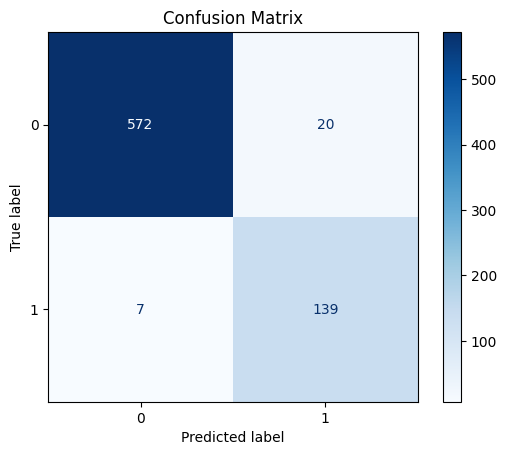

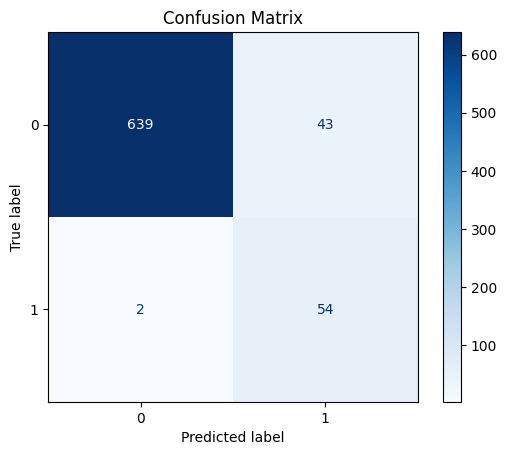

Model Name:  RandomForestClassifier(class_weight={0: 5, 1: 1}, max_depth=6, random_state=42)
Scores: [0.9634146341463414, 0.9390243902439024] F1_scores: [0.9114754098360656, 0.7058823529411765]
Mean Accuracy: 0.9512195121951219
Mean F1 Score: 0.808678881388621


In [ ]:
t_rfc = RandomForestClassifier(random_state=42,max_depth=6,class_weight={0:5,1:1})
validate_model_threshold(t_rfc,X,y)

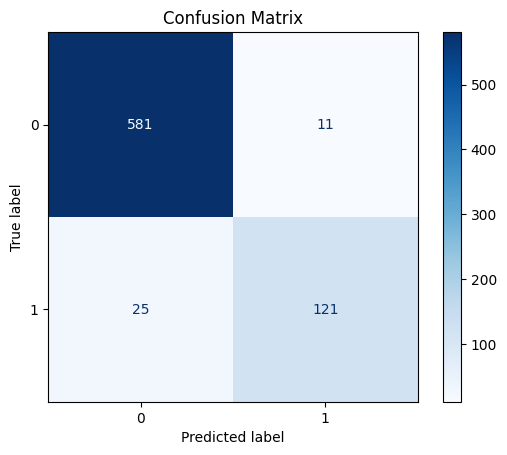

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


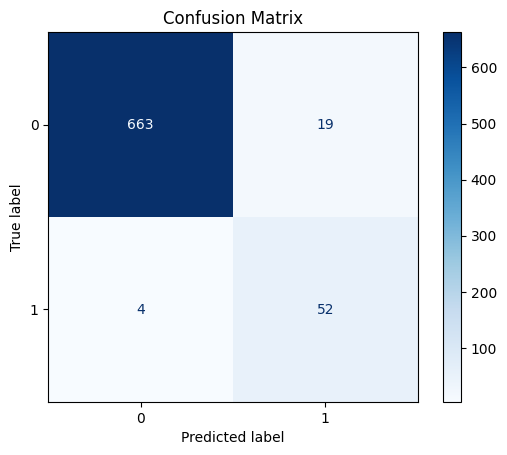

Model Name:  LogisticRegression(max_iter=3000, random_state=42)
Scores: [0.9512195121951219, 0.9688346883468835] F1_scores: [0.8705035971223022, 0.8188976377952756]
Mean Accuracy: 0.9600271002710027
Mean F1 Score: 0.8447006174587889


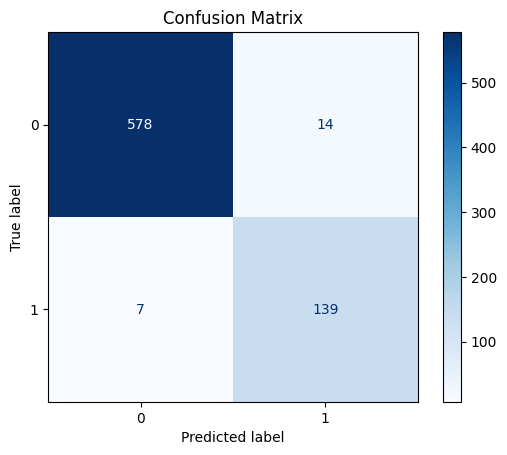

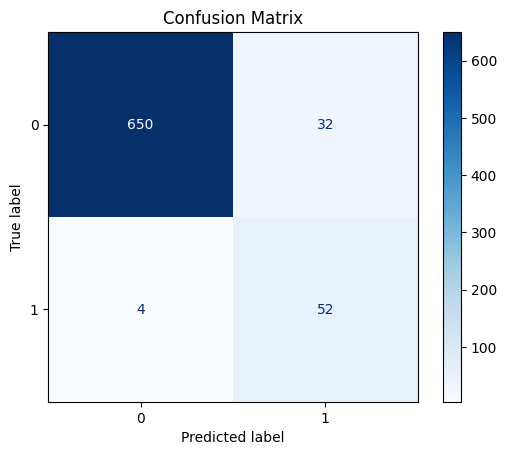

Model Name:  RandomForestClassifier(max_depth=6, random_state=42)
Scores: [0.9715447154471545, 0.9512195121951219] F1_scores: [0.9297658862876255, 0.7428571428571429]
Mean Accuracy: 0.9613821138211383
Mean F1 Score: 0.8363115145723842


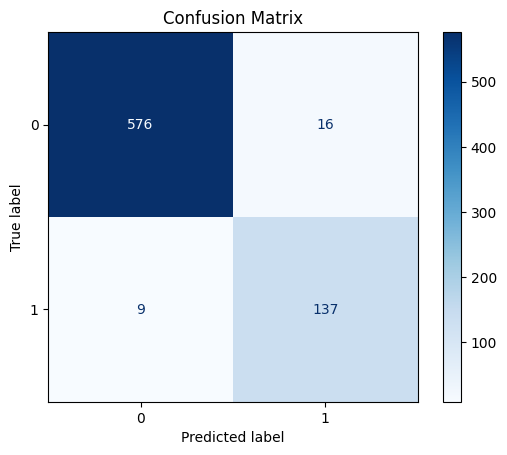

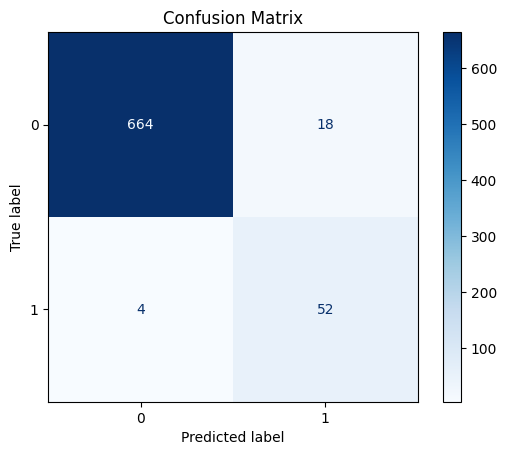

Model Name:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)
Scores: [0.9661246612466124, 0.9701897018970189] F1_scores: [0.9163879598662207, 0.8253968253968254]
Mean Accuracy: 0.9681571815718157
Mean F1 Score: 0.8708923926315231


In [ ]:
validate_model_threshold(clf,X,y)
validate_model_threshold(rfc,X,y)
validate_model_threshold(xgb,X,y)
#validate_model_threshold(svm,X,y)

**Fitting the model on the whole dataset**

In [ ]:
train_mask = (df_train['month'] >= 9)
model_data = df_train[train_mask]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = modeler.feature_importances_

# Get feature names from the training data (x_)
feature_names = x_x.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display the feature importances
print("Feature Importances for XGboost Model:")
display(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

### Sliding Time Series Split

In [ ]:
class SeasonalSlidingTimeSeriesSplit:
    """
    Custom sliding window time series split for seasonal data.
    Respects temporal ordering and allows fixed training window size.
    """

    def __init__(self, n_years_train=5, n_years_test=1, step_years=1):
        """
        Parameters:
        -----------
        n_years_train : int
            Number of years to use for training window
        n_years_test : int
            Number of years to use for testing window
        step_years : int
            How many years to slide forward for each split
        """
        self.n_years_train = n_years_train
        self.n_years_test = n_years_test
        self.step_years = step_years

    def split(self, X, y=None, date_column='date'):
        """
        Generate indices to split data into training and test sets.

        Parameters:
        -----------
        X : pandas DataFrame
            The input features with a date column
        y : array-like, optional
            The target variable
        date_column : str
            Name of the date column in X

        Yields:
        -------
        train_idx : ndarray
            The training set indices for that split
        test_idx : ndarray
            The testing set indices for that split
        """
        # Extract year from date column
        years = pd.to_datetime(X[date_column]).dt.year
        unique_years = sorted(years.unique())

        min_year = min(unique_years)
        max_year = max(unique_years)

        # Generate splits
        current_year = min_year
        split_num = 0

        while current_year + self.n_years_train + self.n_years_test - 1 <= max_year:
            train_start_year = current_year
            train_end_year = current_year + self.n_years_train - 1
            test_start_year = train_end_year + 1
            test_end_year = test_start_year + self.n_years_test - 1

            # Get indices for training and test sets
            train_mask = (years >= train_start_year) & (years <= train_end_year)
            test_mask = (years >= test_start_year) & (years <= test_end_year)

            train_idx = np.where(train_mask)[0]
            test_idx = np.where(test_mask)[0]

            if len(train_idx) > 0 and len(test_idx) > 0:
                split_num += 1
                print(f"\nSplit {split_num}:")
                print(f"  Training years: {train_start_year}-{train_end_year} ({len(train_idx)} samples)")
                print(f"  Testing years: {test_start_year}-{test_end_year} ({len(test_idx)} samples)")

                yield train_idx, test_idx

            current_year += self.step_years

    def get_n_splits(self, X, y=None, date_column='date'):
        """Return the number of splitting iterations."""
        years = pd.to_datetime(X[date_column]).dt.year
        unique_years = sorted(years.unique())
        min_year = min(unique_years)
        max_year = max(unique_years)

        n_splits = 0
        current_year = min_year

        while current_year + self.n_years_train + self.n_years_test - 1 <= max_year:
            n_splits += 1
            current_year += self.step_years

        return n_splits


In [ ]:
X_df_for_split = df_train.reset_index().drop(['dryspell_warn_7d'],axis=1) # Ensure 'date' is a column
y_series_for_split = df_train["dryspell_warn_7d"] # Keep as Series

tscv = SeasonalSlidingTimeSeriesSplit(
    n_years_train=5,  # adjust as needed
    n_years_test=2,
    step_years=1
)
Accuracy_scores=[]
F1_scores=[]
modeler = XGBClassifier(n_estimators=3000,random_state=42,scale_pos_weight=6,max_depth=7)
# Use it
for train_idx, test_idx in tscv.split(X_df_for_split, date_column ='date'): # Pass DataFrame and string column name
    # Use .iloc with the DataFrames/Series
    X_tr, y_tr = X_df_for_split.iloc[train_idx], y_series_for_split.iloc[train_idx]
    X_te, y_te = X_df_for_split.iloc[test_idx], y_series_for_split.iloc[test_idx]

    # Drop the 'date' column before passing to the model, as the model was trained on features without it
    X_tr_model = X_tr.drop('date', axis=1)
    X_te_model = X_te.drop('date', axis=1)

    modeler.fit(X_tr_model, y_tr) # Add this line to fit the model
    proba = modeler.predict_proba(X_te_model)[:, 1]
    y_pred = (proba >= 0.35).astype(int)
    #y_pred = model.predict(X_te_model)


    Accuracy_scores.append(accuracy_score(y_pred,y_te))
    F1_scores.append(f1_score(y_pred,y_te))

print("Model Name: " , modeler)
print("Scores:", Accuracy_scores,"F1_scores:", F1_scores)
print("Mean Accuracy:",np.mean(Accuracy_scores))
print("Mean F1 Score:",np.mean(F1_scores))


Split 1:
  Training years: 2002-2006 (615 samples)
  Testing years: 2007-2008 (246 samples)

Split 2:
  Training years: 2003-2007 (615 samples)
  Testing years: 2008-2009 (246 samples)

Split 3:
  Training years: 2004-2008 (615 samples)
  Testing years: 2009-2010 (246 samples)

Split 4:
  Training years: 2005-2009 (615 samples)
  Testing years: 2010-2011 (246 samples)

Split 5:
  Training years: 2006-2010 (615 samples)
  Testing years: 2011-2012 (246 samples)

Split 6:
  Training years: 2007-2011 (615 samples)
  Testing years: 2012-2013 (246 samples)

Split 7:
  Training years: 2008-2012 (615 samples)
  Testing years: 2013-2014 (246 samples)

Split 8:
  Training years: 2009-2013 (615 samples)
  Testing years: 2014-2015 (246 samples)

Split 9:
  Training years: 2010-2014 (615 samples)
  Testing years: 2015-2016 (246 samples)

Split 10:
  Training years: 2011-2015 (615 samples)
  Testing years: 2016-2017 (246 samples)

Split 11:
  Training years: 2012-2016 (615 samples)
  Testing years:

### **Making Predictions**

In [ ]:
lag_target_feat = lag_target_feat +['dryspell_warn_7d', 'dryspell_warn_7d_lag3']
lag_target_feat

In [ ]:
feature_list =[]
for col in df_train.columns.to_list():
  if col not in lag_target_feat:
    feature_list.append(col)

['dryspell_warn_7d_lag7',
 'target_seasonal_count',
 'target_roll_7',
 'dryspell_warn_7d_lag1',
 'dryspell_warn_7d',
 'dryspell_warn_7d_lag3',
 'dryspell_warn_7d',
 'dryspell_warn_7d_lag3',
 'dryspell_warn_7d',
 'dryspell_warn_7d_lag3']

In [ ]:
def predict_with_lags(model, test_df, features_list):
    """
    model: Trained XGB/LGBM model
    test_df: The 2020-2025 dataframe (must contain weather features)
    features_list: List of weather features (Temp, Pressure, etc.)
    """
    final_preds = []

    # Process each year independently
    for year in test_df['year'].unique():
        year_data = test_df[test_df['year'] == year].copy().sort_index()

        # Initialize lags for the start of the season (July 1st)
        current_lag1 = 0
        history = [] # To track for rolling/expanding features

        for i in range(len(year_data)):
            # 1. Get current day's weather features
            row = year_data.iloc[[i]]

            # 2. Inject the dynamically calculated lags into the row
            # (Matches the names used in your training data)
            row_to_predict = row[features_list].copy()
            row_to_predict['target_lag_1'] = current_lag1
            row_to_predict['target_roll_7'] = np.mean(history[-7:]) if history else 0
            row_to_predict['target_seasonal_count'] = np.sum(history) if history else 0

            # 3. Predict probability and apply your custom threshold
            prob = model.predict_proba(row_to_predict)[:, 1][0]
            pred = 1 if prob >= 0.35 else 0 # Use the best threshold you found

            # 4. Store results
            final_preds.append({'Date': row['Date'].values[0], 'Prediction': pred, 'Prob': prob})

            # 5. Update history for the NEXT day
            current_lag1 = pred
            history.append(pred)

    return pd.DataFrame(final_preds)

# Usage
# Note: features_list should only be your weather columns (Temp, Pressure, etc.)
predictions_df = predict_with_lags(modeler, df_test,feature_list)

In [ ]:
lag_target_feat = lag_target_feat +['dryspell_warn_7d', 'dryspell_warn_7d_lag3']
lag_target_feat

['dryspell_warn_7d_lag7',
 'target_seasonal_count',
 'target_roll_7',
 'dryspell_warn_7d_lag1',
 'dryspell_warn_7d',
 'dryspell_warn_7d_lag3',
 'dryspell_warn_7d',
 'dryspell_warn_7d_lag3']

In [ ]:
x_ = df_train.drop(['dryspell_warn_7d'],axis=1)
y_ = df_train['dryspell_warn_7d']

In [ ]:
modeler.fit(x_,y_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=3000,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
importances = modeler.feature_importances_
featuress = x_.columns
df = pd.DataFrame({'feature': featuress, 'importance': importances})
df.sort_values('importance', ascending=False)
df

,feature,importance
0,sea_level_pressure,0.005228
1,2m_temp,0.023957
2,vapor_pressure_dificit,0.004015
3,5cm_soli_moist,0.029709
4,mean_dew_point_temp,0.028775
5,max_temp,0.006318
6,potential_water_deficit,0.011646
7,day,0.014127
8,year,0.011360
9,dayofyear,0.228984


In [ ]:
best_predictions = modeler.predict(df_test)

In [ ]:
Finaallll_submission = pd.DataFrame({DATE_COL: df_test.index, LABEL_COL: best_predictions})
Finaallll_submission.head()

,date,dryspell_warn_7d
0,2020-07-01,0
1,2020-07-02,0
2,2020-07-03,0
3,2020-07-04,0
4,2020-07-05,0


In [ ]:
Finaallll_submission.dryspell_warn_7d.value_counts()

,count
dryspell_warn_7d,
0,681
1,57


In [ ]:
# X_test = df_test[feature_cols].copy()

proba = modeler.predict_proba(df_test)[:, 1]
pred = (proba >= 0.40).astype(int)
submission = pd.DataFrame({DATE_COL: df_test.index, LABEL_COL: pred})
submission.head()

ValueError: feature_names mismatch: ['sea_level_pressure', '2m_temp', 'vapor_pressure_dificit', '5cm_soli_moist', 'mean_dew_point_temp', 'max_temp', 'potential_water_deficit', 'day', 'year', 'dayofyear', 'Meanvapor_pressure_dificitPerDayOfYear', 'Medianvapor_pressure_dificitPerDayOfYear', 'Meanpotential_water_deficitPerDayOfYear', 'Medianpotential_water_deficitPerDayOfYear', 'Mean5cm_soli_moistPerDayOfYear', 'Median5cm_soli_moistPerDayOfYear', 'Meanmax_tempPerDayOfYear', 'Medianmax_tempPerDayOfYear', '5cm_soli_moist_Lag1', '5cm_soli_moist_Recent_Intensity', 'vapor_pressure_dificit_Lag1', 'vapor_pressure_dificit_Recent_Intensity', 'potential_water_deficit_Lag1', 'potential_water_deficit_Recent_Intensity'] ['sea_level_pressure', '2m_temp', 'vapor_pressure_dificit', '5cm_soli_moist', 'mean_dew_point_temp', 'max_temp', 'potential_water_deficit', 'day', 'year', 'dayofyear', 'Meanvapor_pressure_dificitPerDayOfYear', 'Medianvapor_pressure_dificitPerDayOfYear', 'Meanpotential_water_deficitPerD

In [ ]:
submission.dryspell_warn_7d.value_counts()

,count
dryspell_warn_7d,
0,676
1,62


## 5) Save `submission.csv` and `submission.zip`

The zip file is what you upload to Codabench (result-upload submission).


In [ ]:
out_path = Path("submission.csv")
Finaallll_submission.to_csv(out_path, index=False)
print("Saved:", out_path.resolve())


Saved: /content/submission.csv


In [ ]:
import zipfile
from pathlib import Path
out_path = Path("submission.csv")
zip_path = Path("submission.zip")
with zipfile.ZipFile(zip_path, mode="w", compression=zipfile.ZIP_DEFLATED) as zf:
    # Put submission.csv at the ZIP root (no folders)
    zf.write(out_path, arcname="submission.csv")

print("Zipped:", zip_path.resolve())


Zipped: /content/submission.zip


In [ ]:
xgb_importances

,Feature,Importance,Model
7,dayofyear,0.550847,XGBoost
3,day,0.121172,XGBoost
5,year,0.095216,XGBoost
8,5cm_soli_moist,0.041483,XGBoost
14,Mean5cm_soli_moistPerDayOfYear,0.034502,XGBoost
1,2m_temp,0.033727,XGBoost
10,Meanvapor_pressure_dificitPerDayOfYear,0.029953,XGBoost
2,vapor_pressure_dificit,0.029078,XGBoost
12,Meansea_level_pressurePerDayOfYear,0.020347,XGBoost
0,sea_level_pressure,0.015569,XGBoost
